In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Смотрим общую информацию и пропуски в таблице

In [97]:
df = pd.read_csv("behavior_label.csv") ## считываем таблицу
df


,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1.0,17.996005,1.400050,Distracted
1,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1.0,29.904182,1.428537,Distracted
2,71.314445,3.638434,0.789375,79.734087,-6.100238,78.110507,0.254723,0.0,11.126012,0.406950,Aggressive
3,86.485997,2.441366,0.039135,45.007002,17.886191,82.794935,0.911664,0.0,11.064505,0.539964,Aggressive
4,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1.0,21.967570,1.369908,Distracted
...,...,...,...,...,...,...,...,...,...,...,...
29995,53.793871,0.630921,0.338402,26.264227,1.380436,32.252103,0.934973,1.0,27.011128,NaN,Distracted
29996,47.963150,0.578964,0.073692,22.825827,9.846702,34.785630,0.255194,0.0,42.445077,0.710229,NaN
29997,49.804551,1.377664,0.546392,49.951452,NaN,39.792856,0.524941,1.0,25.878929,1.449100,Distracted
29998,44.326306,0.421080,0.127109,0.738540,12.019311,29.867322,0.309540,0.0,41.039219,NaN,Safe


In [98]:
df.columns ## смотрим наши столбцы


Index(['speed_kmph', 'accel_x', 'accel_y', 'brake_pressure', 'steering_angle',
       'throttle', 'lane_deviation', 'phone_usage', 'headway_distance',
       'reaction_time', 'behavior_label'],
      dtype='str')

In [99]:
df.dtypes

speed_kmph          float64
accel_x             float64
accel_y             float64
brake_pressure      float64
steering_angle      float64
throttle            float64
lane_deviation      float64
phone_usage         float64
headway_distance    float64
reaction_time       float64
behavior_label          str
dtype: object

In [100]:
df.info() ## мы просматриваем какого типа данные у нас в таблицы, а также нулевые и не нулевые значения

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmph        30000 non-null  float64
 1   accel_x           30000 non-null  float64
 2   accel_y           30000 non-null  float64
 3   brake_pressure    30000 non-null  float64
 4   steering_angle    26972 non-null  float64
 5   throttle          30000 non-null  float64
 6   lane_deviation    30000 non-null  float64
 7   phone_usage       28475 non-null  float64
 8   headway_distance  30000 non-null  float64
 9   reaction_time     28338 non-null  float64
 10  behavior_label    27908 non-null  str    
dtypes: float64(10), str(1)
memory usage: 2.5 MB


In [101]:
df.describe() # просматриваем количество данных, максимум, минимум и значения в 25% 50% и 75%

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time
count,30000.000000,30000.000000,30000.000000,30000.000000,26972.000000,30000.000000,30000.000000,28475.000000,30000.000000,28338.000000
mean,60.337295,1.265818,0.368501,40.798294,-0.012423,55.001223,0.568549,0.333521,23.346700,0.998643
std,19.024663,1.026624,0.295654,27.766434,11.363309,21.475323,0.420563,0.471479,12.113801,0.465888
min,20.000000,-0.949617,-0.479718,-312.496093,-59.989984,20.001444,0.000001,0.000000,-64.678416,0.400034
25%,49.582614,0.506529,0.116047,18.713550,-6.156862,37.246356,0.234971,0.000000,13.660647,0.623806
50%,57.919075,0.831602,0.313145,39.952920,-0.008215,50.066483,0.456616,0.000000,20.115701,0.850083
75%,69.292433,1.968167,0.568768,57.933765,6.139021,70.144059,0.810950,1.000000,31.301648,1.394386
max,861.116020,5.308924,1.664605,518.998710,53.426806,99.994762,2.425784,1.000000,49.998924,1.999885


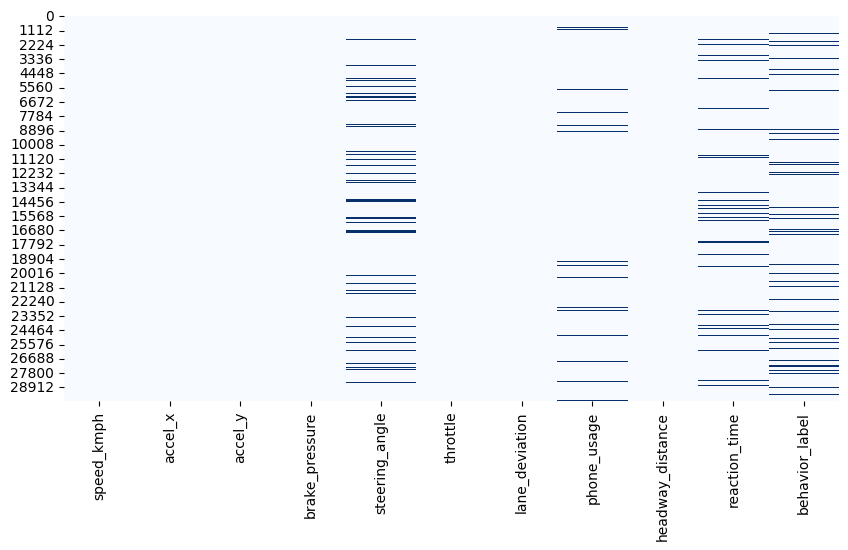

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar = False, cmap = 'Blues')
plt.show()

## смотрим пропуски в нашей таблице, синее это то что нужно удалить/заменить/определить

In [103]:
df.isnull().sum() ## общие пропуски в таблице

speed_kmph             0
accel_x                0
accel_y                0
brake_pressure         0
steering_angle      3028
throttle               0
lane_deviation         0
phone_usage         1525
headway_distance       0
reaction_time       1662
behavior_label      2092
dtype: int64

Изучаем столбец steering_angle

In [104]:
df['steering_angle'].unique() ## очень много различных значений - следовательно будем использовать метод среднего арифметического для замены данных

array([ -3.16995609, -24.38008154,  -6.10023785, ...,   9.84670168,
        12.01931136,  10.35921223], shape=(26973,))

In [105]:
df['steering_angle'].median() ## среднее значение из всех данных столбца

np.float64(-0.00821546290222175)

In [106]:
df.fillna({'steering_angle': df['steering_angle'].median()}, inplace = True) ## непосредственно замена нулевых данных на среднее значение

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1.0,17.996005,1.400050,Distracted
1,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1.0,29.904182,1.428537,Distracted
2,71.314445,3.638434,0.789375,79.734087,-6.100238,78.110507,0.254723,0.0,11.126012,0.406950,Aggressive
3,86.485997,2.441366,0.039135,45.007002,17.886191,82.794935,0.911664,0.0,11.064505,0.539964,Aggressive
4,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1.0,21.967570,1.369908,Distracted
...,...,...,...,...,...,...,...,...,...,...,...
29995,53.793871,0.630921,0.338402,26.264227,1.380436,32.252103,0.934973,1.0,27.011128,NaN,Distracted
29996,47.963150,0.578964,0.073692,22.825827,9.846702,34.785630,0.255194,0.0,42.445077,0.710229,NaN
29997,49.804551,1.377664,0.546392,49.951452,-0.008215,39.792856,0.524941,1.0,25.878929,1.449100,Distracted
29998,44.326306,0.421080,0.127109,0.738540,12.019311,29.867322,0.309540,0.0,41.039219,NaN,Safe


In [107]:
df['steering_angle'].isnull().sum() ## смотрим сколько у нас нулевых данных, должно быть 0 после замены

np.int64(0)

Изучаем столбец phone_usage

In [108]:
df['phone_usage'].unique() ## всего 2 значение, следовательно лучше всего заменить на моду(самое частое значение)

array([ 1.,  0., nan])

In [109]:
df['phone_usage'].mode() ## самое частое значение

0    0.0
Name: phone_usage, dtype: float64

In [110]:
(df['phone_usage'] == 1).sum() ## значений 1 моды

np.int64(9497)

In [111]:
(df['phone_usage'] == 0).sum() ## 0 значений больше чем 1

np.int64(18978)

In [112]:
## так как значений 0 больше, а их всего 2, я заменю пропуски на 1, для более средних значений, зная что пропусков всего 1500
df.fillna({'phone_usage': 1}, inplace = True)

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1.0,17.996005,1.400050,Distracted
1,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1.0,29.904182,1.428537,Distracted
2,71.314445,3.638434,0.789375,79.734087,-6.100238,78.110507,0.254723,0.0,11.126012,0.406950,Aggressive
3,86.485997,2.441366,0.039135,45.007002,17.886191,82.794935,0.911664,0.0,11.064505,0.539964,Aggressive
4,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1.0,21.967570,1.369908,Distracted
...,...,...,...,...,...,...,...,...,...,...,...
29995,53.793871,0.630921,0.338402,26.264227,1.380436,32.252103,0.934973,1.0,27.011128,NaN,Distracted
29996,47.963150,0.578964,0.073692,22.825827,9.846702,34.785630,0.255194,0.0,42.445077,0.710229,NaN
29997,49.804551,1.377664,0.546392,49.951452,-0.008215,39.792856,0.524941,1.0,25.878929,1.449100,Distracted
29998,44.326306,0.421080,0.127109,0.738540,12.019311,29.867322,0.309540,0.0,41.039219,NaN,Safe


In [113]:
df["phone_usage"].isnull().sum() ## проверка нулевых значений столбца phone_usage, их 0 всё отлично

np.int64(0)

Изучаем столбец reaction_time

In [114]:
df["reaction_time"].unique() ## смотрим уникальные значение - много вещественных, значит будем использовать среднее или медиану

array([1.40004971, 1.42853669, 0.40694984, ..., 0.71022936, 1.4491003 ,
       0.63971785], shape=(28339,))

In [115]:
df["reaction_time"].mean() # среднее значение

np.float64(0.9986431065894303)

In [116]:
df['reaction_time'].median() # медиана

np.float64(0.8500834222469208)

In [117]:
df['reaction_time'].min() # минимальное значение

np.float64(0.4000336419091121)

In [118]:
df['reaction_time'].max() # максимальное значение

np.float64(1.9998853035759176)

In [119]:
# при учете минимальных и максимальных значение, самое оптимальное как будто бы среднее значение, будем менять на него
df.fillna({'reaction_time': df['reaction_time'].mean()}, inplace = True)

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1.0,17.996005,1.400050,Distracted
1,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1.0,29.904182,1.428537,Distracted
2,71.314445,3.638434,0.789375,79.734087,-6.100238,78.110507,0.254723,0.0,11.126012,0.406950,Aggressive
3,86.485997,2.441366,0.039135,45.007002,17.886191,82.794935,0.911664,0.0,11.064505,0.539964,Aggressive
4,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1.0,21.967570,1.369908,Distracted
...,...,...,...,...,...,...,...,...,...,...,...
29995,53.793871,0.630921,0.338402,26.264227,1.380436,32.252103,0.934973,1.0,27.011128,0.998643,Distracted
29996,47.963150,0.578964,0.073692,22.825827,9.846702,34.785630,0.255194,0.0,42.445077,0.710229,NaN
29997,49.804551,1.377664,0.546392,49.951452,-0.008215,39.792856,0.524941,1.0,25.878929,1.449100,Distracted
29998,44.326306,0.421080,0.127109,0.738540,12.019311,29.867322,0.309540,0.0,41.039219,0.998643,Safe


In [120]:
df['reaction_time'].isnull().sum() # проверка нулевых

np.int64(0)

Остался последний столбец behavior_label

In [121]:
df['behavior_label'].unique() # всего несколько значений, самое оптимальное для использование - мода

<StringArray>
['Distracted', 'Aggressive', 'Safe', nan]
Length: 4, dtype: str

In [122]:
df['behavior_label'].value_counts() ## всего пропусков 2000, мода - aggressive

behavior_label
Aggressive    9333
Distracted    9308
Safe          9267
Name: count, dtype: int64

In [123]:
df.fillna({'behavior_label': 'aggressive'}, inplace = True) ## замена на другое значение

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1.0,17.996005,1.400050,Distracted
1,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1.0,29.904182,1.428537,Distracted
2,71.314445,3.638434,0.789375,79.734087,-6.100238,78.110507,0.254723,0.0,11.126012,0.406950,Aggressive
3,86.485997,2.441366,0.039135,45.007002,17.886191,82.794935,0.911664,0.0,11.064505,0.539964,Aggressive
4,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1.0,21.967570,1.369908,Distracted
...,...,...,...,...,...,...,...,...,...,...,...
29995,53.793871,0.630921,0.338402,26.264227,1.380436,32.252103,0.934973,1.0,27.011128,0.998643,Distracted
29996,47.963150,0.578964,0.073692,22.825827,9.846702,34.785630,0.255194,0.0,42.445077,0.710229,aggressive
29997,49.804551,1.377664,0.546392,49.951452,-0.008215,39.792856,0.524941,1.0,25.878929,1.449100,Distracted
29998,44.326306,0.421080,0.127109,0.738540,12.019311,29.867322,0.309540,0.0,41.039219,0.998643,Safe


In [124]:
df['behavior_label'].isnull().sum() ## проверка показывает 0 пропусков

np.int64(0)

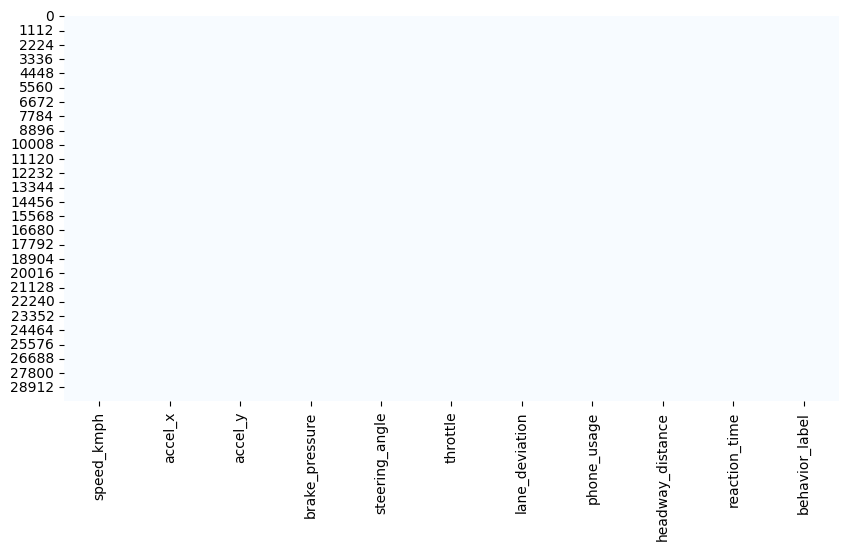

In [125]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar = False, cmap = 'Blues')
plt.show()

In [126]:
## карта показывает что пропусков больше нету

Дубликаты

In [127]:
df.duplicated().sum() ## дубликатов не обнаружено

np.int64(0)

Проверка выбросов и обработка

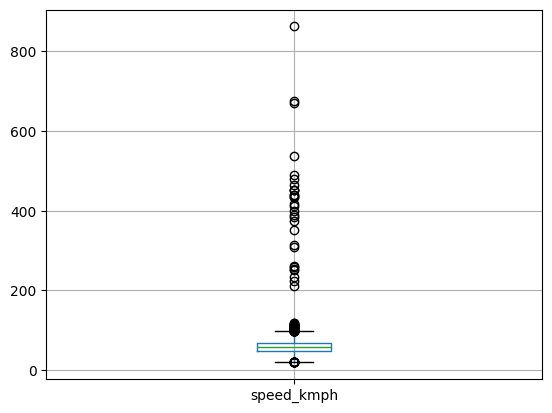

In [128]:
boxplot = df.boxplot(column=["speed_kmph"]) # мы просматриваем значение speed, скорость выше 150 уже невероятно большая, убираем

In [129]:
df = df[df['speed_kmph'] < 140] ## убираем выбросы

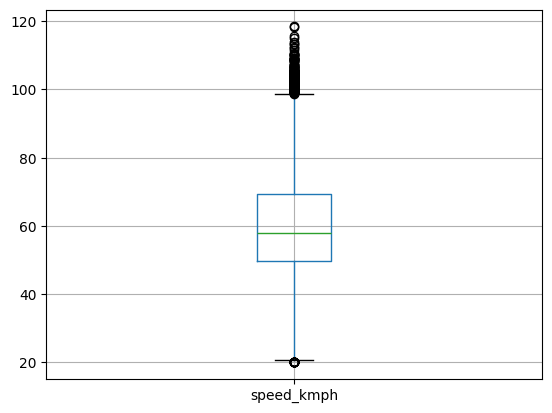

In [130]:
boxplot = df.boxplot(column=["speed_kmph"]) ## проверяем после удаления

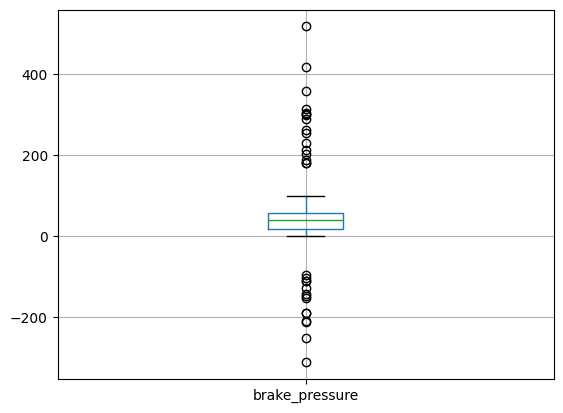

In [131]:
boxplot = df.boxplot(column=["brake_pressure"]) # в датасете указано что там значение в процентах, отрицательные значение убираем и максимум 100

In [132]:
df = df[df['brake_pressure'] < 100] ## убираем выбросы
df = df[df['brake_pressure'] > 0]

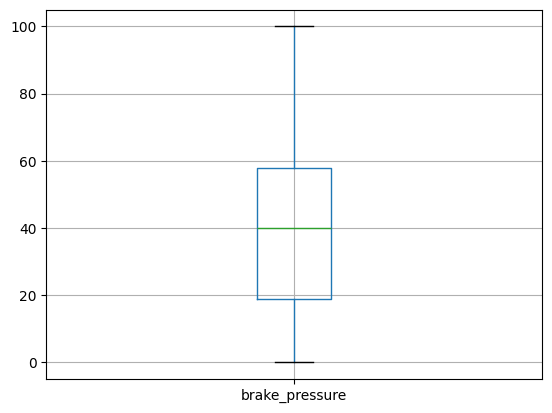

In [133]:
boxplot = df.boxplot(column=["brake_pressure"]) ## проверка после удаления

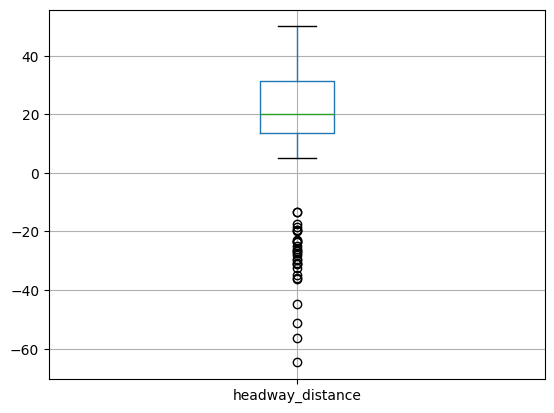

In [134]:
boxplot = df.boxplot(column=["headway_distance"]) ## это у нас расстояние путешествия, оно отрицательным не может быть, следовательно убираем

In [135]:
df = df[df['headway_distance'] > 0] ## убираем выбросы

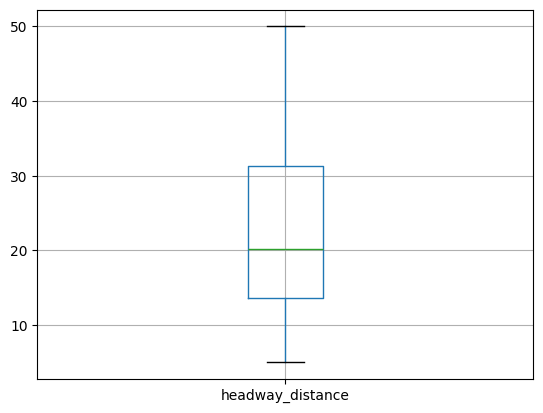

In [136]:
boxplot = df.boxplot(column=["headway_distance"]) ## проверка

In [137]:
df.describe() ## смотрим максимальные и минимальные данные, на просмотр выбросов

,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time
count,29910.000000,29910.000000,29910.000000,29910.000000,29910.000000,29910.000000,29910.000000,29910.000000,29910.000000,29910.000000
mean,59.980150,1.265523,0.368455,40.763305,-0.009063,54.993324,0.568633,0.367503,23.402860,0.998754
std,14.803004,1.026508,0.295591,26.721899,10.767636,21.473602,0.420662,0.482133,11.998281,0.452704
min,20.000000,-0.949617,-0.479718,0.003128,-59.989984,20.001444,0.000001,0.000000,5.004359,0.400034
25%,49.570544,0.506353,0.116030,18.719026,-5.273610,37.245618,0.235047,0.000000,13.685240,0.637698
50%,57.897797,0.831483,0.313075,39.925842,-0.008215,50.027023,0.456673,0.000000,20.139378,0.875429
75%,69.228882,1.965294,0.568740,57.914454,5.294539,70.134850,0.811570,1.000000,31.308969,1.360993
max,118.439831,5.308924,1.664605,99.994365,53.426806,99.994762,2.425784,1.000000,49.998924,1.999885


Все данные почищены выбросов больше не обнаружено

Корреляция

In [138]:
df.info() ## нужно преобразовать строку в число

<class 'pandas.DataFrame'>
Index: 29910 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmph        29910 non-null  float64
 1   accel_x           29910 non-null  float64
 2   accel_y           29910 non-null  float64
 3   brake_pressure    29910 non-null  float64
 4   steering_angle    29910 non-null  float64
 5   throttle          29910 non-null  float64
 6   lane_deviation    29910 non-null  float64
 7   phone_usage       29910 non-null  float64
 8   headway_distance  29910 non-null  float64
 9   reaction_time     29910 non-null  float64
 10  behavior_label    29910 non-null  str    
dtypes: float64(10), str(1)
memory usage: 2.7 MB


Я изменю данные aggressive, safe, Distracted на числовые значения

In [139]:
rep_df = df.replace({'behavior_label': {'Safe': 0, 'Aggressive':1, 'aggressive':1, 'Distracted':2}}) ## замена

In [140]:
rep_df["behavior_label"].unique() # проверка замены


array([2, 1, 0], dtype=object)

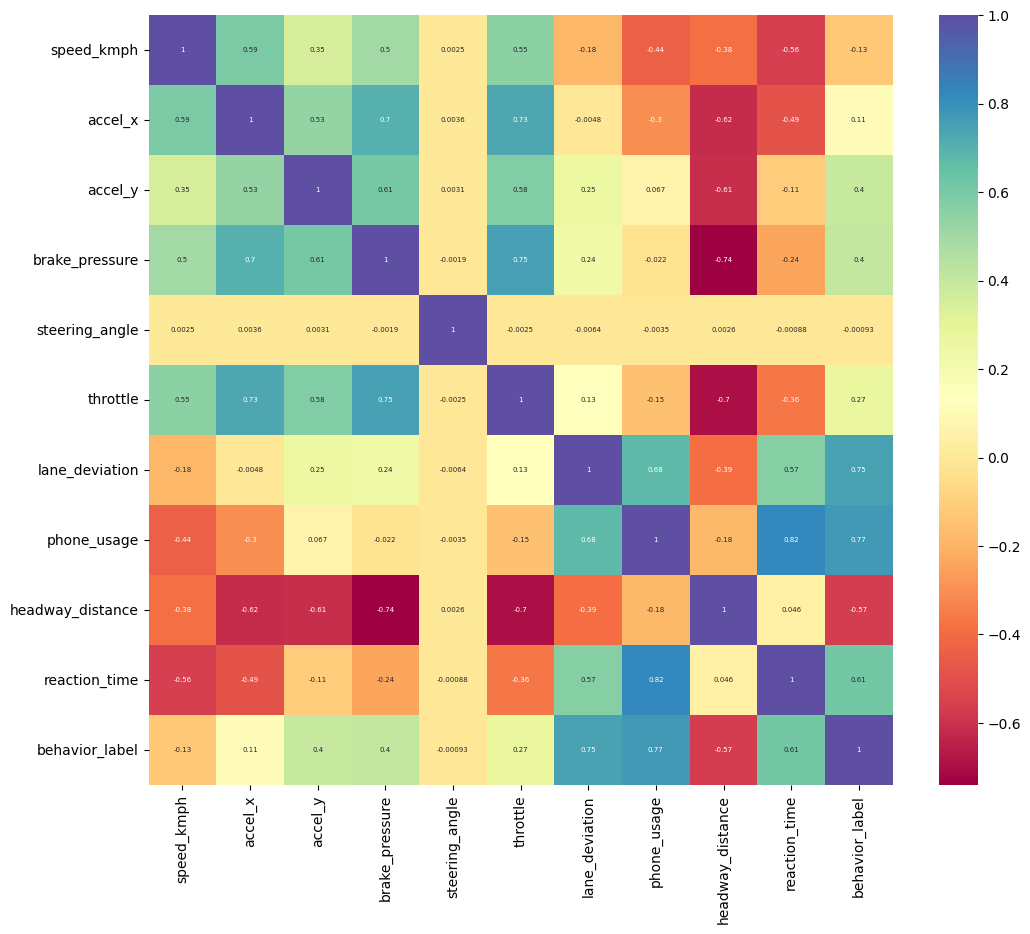

In [141]:
plt.figure(figsize=(12,10))
sns.heatmap(rep_df.corr(),cmap="Spectral", annot= True, annot_kws={'size':5})
plt.show()

In [142]:
df.info()

<class 'pandas.DataFrame'>
Index: 29910 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmph        29910 non-null  float64
 1   accel_x           29910 non-null  float64
 2   accel_y           29910 non-null  float64
 3   brake_pressure    29910 non-null  float64
 4   steering_angle    29910 non-null  float64
 5   throttle          29910 non-null  float64
 6   lane_deviation    29910 non-null  float64
 7   phone_usage       29910 non-null  float64
 8   headway_distance  29910 non-null  float64
 9   reaction_time     29910 non-null  float64
 10  behavior_label    29910 non-null  str    
dtypes: float64(10), str(1)
memory usage: 2.7 MB


In [143]:
rep_df.info()

<class 'pandas.DataFrame'>
Index: 29910 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmph        29910 non-null  float64
 1   accel_x           29910 non-null  float64
 2   accel_y           29910 non-null  float64
 3   brake_pressure    29910 non-null  float64
 4   steering_angle    29910 non-null  float64
 5   throttle          29910 non-null  float64
 6   lane_deviation    29910 non-null  float64
 7   phone_usage       29910 non-null  float64
 8   headway_distance  29910 non-null  float64
 9   reaction_time     29910 non-null  float64
 10  behavior_label    29910 non-null  object 
dtypes: float64(10), object(1)
memory usage: 2.7+ MB
